In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/15
    print("準備完了！このまま下のセルを実行できます。")

# 第15章 離散潜在変数 (Discrete Latent Variables)
## 15.4 変分下界 (Evidence Lower Bound; ELBO)

本ノートブックでは、Christopher M. Bishop & Hugh Bishop 著『Deep Learning: Foundations and Concepts』(2024年) 第15章「Discrete Latent Variables」の**第15.4節「Evidence Lower Bound」**および各小節の内容を、完全数式導出・変分分解の証明・グラフィカルモデル・数値検証・図版再現を通して解説します。

---

### 目次
1. [変分下界 (ELBO) と対数尤度の分解](#1.-変分下界-(ELBO)-と対数尤度の分解)
   - 観測変数・潜在変数・パラメータの定式化 (Equation 15.51)
   - 任意の分布 $q(\mathbf{Z})$ に対する基本分解定理 (Equation 15.52)
   - 変分下界 $\mathcal{L}(q, \boldsymbol{\theta})$ の定義 (Equation 15.53)
   - カルバック・ライブラー情報量 $\mathrm{KL}(q \parallel p)$ の定義と非負性 (Equation 15.54)
   - 分解の図解 (Figure 15.13)
2. [第15.4.1項 EMアルゴリズムの再訪 (EM revisited)](#2.-第15.4.1項-EMアルゴリズムの再訪-(EM-revisited))
   - Eステップの本質: KL情報量の最小化と下界の飽和 (Figure 15.14)
   - Mステップの本質: 下界の最大化と尤度の増加保証 (Figure 15.15)
   - 完全データ対数尤度の期待値 $Q(\boldsymbol{\theta}, \boldsymbol{\theta}^{\text{old}})$ との関係 (Equation 15.56)
   - パラメータ空間におけるEMの幾何学的解釈 (Figure 15.16)
3. [第15.4.2項 独立同分布データ (Independent and identically distributed data)](#3.-第15.4.2項-独立同分布データ-(Independent-and-identically-distributed-data))
   - 事後分布のデータ点ごとの独立因数分解 (Equation 15.57)
   - 完全データのグラフィカルモデル (Figure 15.10)
   - 系列データへの拡張: 隠れマルコフモデル (HMM, Figure 15.11)
4. [第15.4.3項 パラメータの事前分布 (Parameter priors: MAP EM)](#4.-第15.4.3項-パラメータの事前分布-(Parameter-priors:-MAP-EM))
   - 事後確率最大化 (MAP) の変分下界 (Equations 15.58 - 15.59)
   - 正則化項による尤度関数の特異点 (Singularity) 解消
5. [第15.4.4項 一般化EM (Generalized EM; GEM)](#5.-第15.4.4項-一般化EM-(Generalized-EM;-GEM))
   - Mステップの緩和: 部分的下界増加 (ECM, 勾配上昇法)
   - Eステップの緩和: 変分推論 (Variational Inference) への接続
6. [第15.4.5項 逐次型EM (Sequential EM)](#6.-第15.4.5項-逐次型EM-(Sequential-EM))
   - オンライン・逐次更新アルゴリズムの導出 (Equations 15.60 - 15.61)
   - 十分統計量のインクリメンタル更新と数値検証
7. [第15章全体の総括と第16章（連続潜在変数）への展望](#7.-第15章全体の総括と第16章（連続潜在変数）への展望)


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

# プロジェクトルートの設定
project_root = Path.cwd().parent if Path.cwd().name == '15' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from common.kmeans_clustering import load_faithful_dataset
from common.evidence_lower_bound import (
    compute_elbo_decomposition,
    SequentialGaussianMixtureEM,
    MAPGaussianMixtureEM,
    generate_figure_15_10,
    generate_figure_15_11,
    generate_figure_15_13,
    generate_figure_15_14,
    generate_figure_15_15,
    generate_figure_15_16,
)

print("Dependencies and modules loaded successfully!")


Dependencies and modules loaded successfully!


## 1. 変分下界 (ELBO) と対数尤度の分解

前節（15.3節）では、不完全データの尤度関数を直接最大化する代わりに、事後負担率を用いた交代最適化を行うEMアルゴリズムを学びました。
ここでは、EMアルゴリズムを**変分下界 (Evidence Lower Bound; ELBO)** の観点から統一的かつ普遍的な枠組みとして再定式化します。

---

### 数学的枠組み

観測されたすべての変数を $\mathbf{X}$、すべての潜在変数を $\mathbf{Z}$、モデルの全パラメータを $\boldsymbol{\theta}$ と表記します。
モデルの同時確率分布 $p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\theta})$ に対し、最大化したい不完全データの対数尤度関数は、潜在変数を周辺化（周辺和）することで得られます (テキスト式 15.51)：

$$\ln p(\mathbf{X} \mid \boldsymbol{\theta}) = \ln \sum_{\mathbf{Z}} p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\theta}) \tag{15.51}$$

ここで、潜在変数 $\mathbf{Z}$ 上の**任意の確率分布** $q(\mathbf{Z})$ を導入します（$\sum_{\mathbf{Z}} q(\mathbf{Z}) = 1, q(\mathbf{Z}) \ge 0$）。

任意の $q(\mathbf{Z})$ に対して、次の**完全な分解恒等式**が厳密に成立します (テキスト式 15.52)：

$$\ln p(\mathbf{X} \mid \boldsymbol{\theta}) = \mathcal{L}(q, \boldsymbol{\theta}) + \mathrm{KL}(q \parallel p) \tag{15.52}$$

ここで、$\mathcal{L}(q, \boldsymbol{\theta})$ は**変分下界 (Evidence Lower Bound; ELBO)** と呼ばれ、次式で定義されます (テキスト式 15.53)：

$$\mathcal{L}(q, \boldsymbol{\theta}) = \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln \left\{ \frac{p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\theta})}{q(\mathbf{Z})} \right\} \tag{15.53}$$

また、$\mathrm{KL}(q \parallel p)$ は分布 $q(\mathbf{Z})$ と真の事後分布 $p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta})$ との間の**カルバック・ライブラー情報量 (Kullback–Leibler divergence)** です (テキスト式 15.54)：

$$\mathrm{KL}(q \parallel p) = - \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln \left\{ \frac{p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta})}{q(\mathbf{Z})} \right\} = \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln \left\{ \frac{q(\mathbf{Z})}{p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta})} \right\} \tag{15.54}$$

---

### 分解の厳密証明

乗法定理 $p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\theta}) = p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta}) p(\mathbf{X} \mid \boldsymbol{\theta})$ の両辺の対数を取ると：

$$\ln p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\theta}) = \ln p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta}) + \ln p(\mathbf{X} \mid \boldsymbol{\theta}) \tag{15.55}$$

これを式 (15.53) の下界 $\mathcal{L}(q, \boldsymbol{\theta})$ に代入します：

$$\begin{aligned}
\mathcal{L}(q, \boldsymbol{\theta}) &= \sum_{\mathbf{Z}} q(\mathbf{Z}) \left[ \ln p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta}) + \ln p(\mathbf{X} \mid \boldsymbol{\theta}) - \ln q(\mathbf{Z}) \right] \\
&= \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln p(\mathbf{X} \mid \boldsymbol{\theta}) + \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln \left\{ \frac{p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta})}{q(\mathbf{Z})} \right\} \\
&= \ln p(\mathbf{X} \mid \boldsymbol{\theta}) \underbrace{\sum_{\mathbf{Z}} q(\mathbf{Z})}_{= 1} - \underbrace{\left( - \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln \left\{ \frac{p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta})}{q(\mathbf{Z})} \right\} \right)}_{\mathrm{KL}(q \parallel p)} \\
&= \ln p(\mathbf{X} \mid \boldsymbol{\theta}) - \mathrm{KL}(q \parallel p)
\end{aligned}$$

移項すると直ちに式 (15.52) が得られます。

KLダイバージェンスの基本的性質（イェンセンの不等式、第2章2.5節参照）より、常に $\mathrm{KL}(q \parallel p) \ge 0$ であり、等号成立は $q(\mathbf{Z}) = p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta})$ のときに限られます。
したがって、次式が必ず成り立ちます：

$$\mathcal{L}(q, \boldsymbol{\theta}) \le \ln p(\mathbf{X} \mid \boldsymbol{\theta})$$

これが、$\mathcal{L}(q, \boldsymbol{\theta})$ が「エビデンス（対数尤度）の下界 (Evidence Lower Bound)」と呼ばれる所以です。


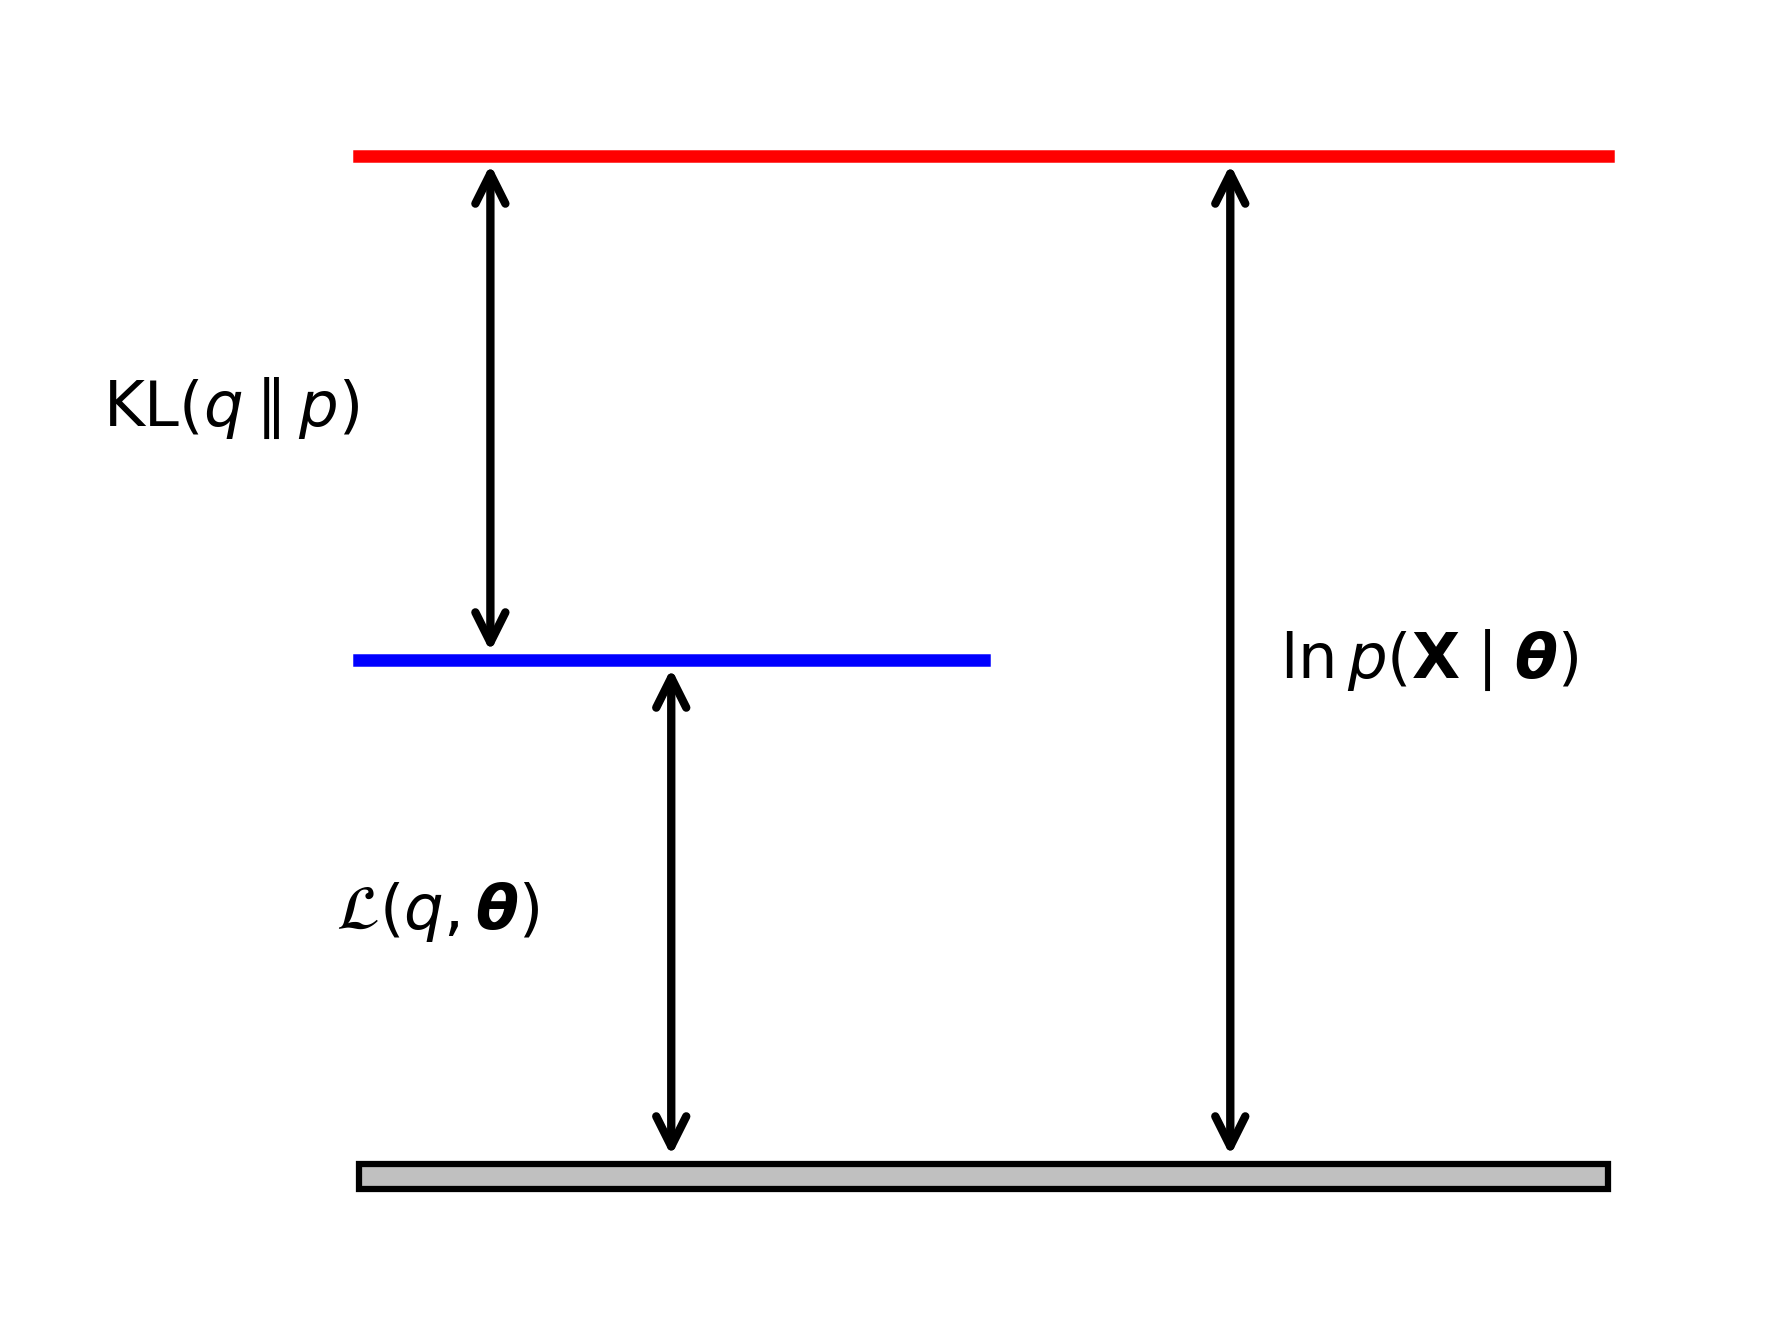

Log-Likelihood ln p(X|theta):  -1150.201664
ELBO L(q, theta):             -1277.365764
KL Divergence KL(q || p):     127.164099
Sum (ELBO + KL):              -1150.201664
Discrepancy:                  0.00e+00


In [2]:
# Figure 15.13: 対数尤度分解の可視化
fig_path_15_13 = project_root / "15" / "result" / "fig_15_13_elbo_decomposition.png"
generate_figure_15_13(fig_path_15_13)
display(Image(filename=str(fig_path_15_13)))

# 数値実験による分解恒等式 ln p(X) = ELBO + KL の完全検証
X_std, _ = load_faithful_dataset()
means = np.array([[-1.5, 1.0], [1.5, -1.0]])
covs = np.array([np.eye(2), np.eye(2)])
weights = np.array([0.5, 0.5])

# ランダムな非最適 q 分布で評価
rng = np.random.RandomState(42)
q_arbitrary = rng.dirichlet(alpha=[1.0, 1.0], size=len(X_std))

decomp = compute_elbo_decomposition(X_std, means, covs, weights, q=q_arbitrary)
print(f"Log-Likelihood ln p(X|theta):  {decomp['log_likelihood']:.6f}")
print(f"ELBO L(q, theta):             {decomp['elbo']:.6f}")
print(f"KL Divergence KL(q || p):     {decomp['kl_divergence']:.6f}")
print(f"Sum (ELBO + KL):              {decomp['elbo'] + decomp['kl_divergence']:.6f}")
print(f"Discrepancy:                  {abs(decomp['log_likelihood'] - (decomp['elbo'] + decomp['kl_divergence'])):.2e}")


## 2. 第15.4.1項 EMアルゴリズムの再訪 (EM revisited)

この分解式 (15.52) を用いると、EMアルゴリズムの Eステップと Mステップが、下界 $\mathcal{L}(q, \boldsymbol{\theta})$ に対する交代最大化（coordinate ascent）として極めて明快に解釈できます。

現在のパラメータを $\boldsymbol{\theta}^{\text{old}}$ とします。

---

### Eステップの幾何学的解釈 (Figure 15.14)
- **操作**: パラメータ $\boldsymbol{\theta}^{\text{old}}$ を固定し、分布 $q(\mathbf{Z})$ に関して下界 $\mathcal{L}(q, \boldsymbol{\theta}^{\text{old}})$ を最大化する。
- **解**: 目的関数 $\ln p(\mathbf{X} \mid \boldsymbol{\theta}^{\text{old}})$ は $q(\mathbf{Z})$ に一切依存しない定数です。したがって、下界 $\mathcal{L}$ を最大化することは、$\mathrm{KL}(q \parallel p)$ を最小化（0 に）することと完全に等価です。
- **結果**: 
  $$q(\mathbf{Z}) = p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta}^{\text{old}})$$
  これにより、$\mathrm{KL}(q \parallel p) = 0$ となり、下界は対数尤度に一致します：
  $$\mathcal{L}(q, \boldsymbol{\theta}^{\text{old}}) = \ln p(\mathbf{X} \mid \boldsymbol{\theta}^{\text{old}})$$

---

### Mステップの幾何学的解釈 (Figure 15.15)
- **操作**: Eステップで求めた分布 $q(\mathbf{Z})$ を固定し、パラメータ $\boldsymbol{\theta}$ に関して下界 $\mathcal{L}(q, \boldsymbol{\theta})$ を最大化して新しいパラメータ $\boldsymbol{\theta}^{\text{new}}$ を求める。
- **結果**: 下界の値は $\mathcal{L}(q, \boldsymbol{\theta}^{\text{old}})$ から $\mathcal{L}(q, \boldsymbol{\theta}^{\text{new}})$ へと増加します。
- **対数尤度の増加保証**: 
  $$\ln p(\mathbf{X} \mid \boldsymbol{\theta}^{\text{new}}) = \mathcal{L}(q, \boldsymbol{\theta}^{\text{new}}) + \underbrace{\mathrm{KL}(q \parallel p(\cdot \mid \mathbf{X}, \boldsymbol{\theta}^{\text{new}}))}_{\ge 0}$$
  Mステップでは $q$ は古いパラメータ $\boldsymbol{\theta}^{\text{old}}$ のもとでの事後分布に固定されたままなので、新しい事後分布 $p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta}^{\text{new}})$ との間には正の KLダイバージェンスが生じます。
  したがって、対数尤度 $\ln p(\mathbf{X} \mid \boldsymbol{\theta})$ の増加量は、下界の増加量**以上**になります！


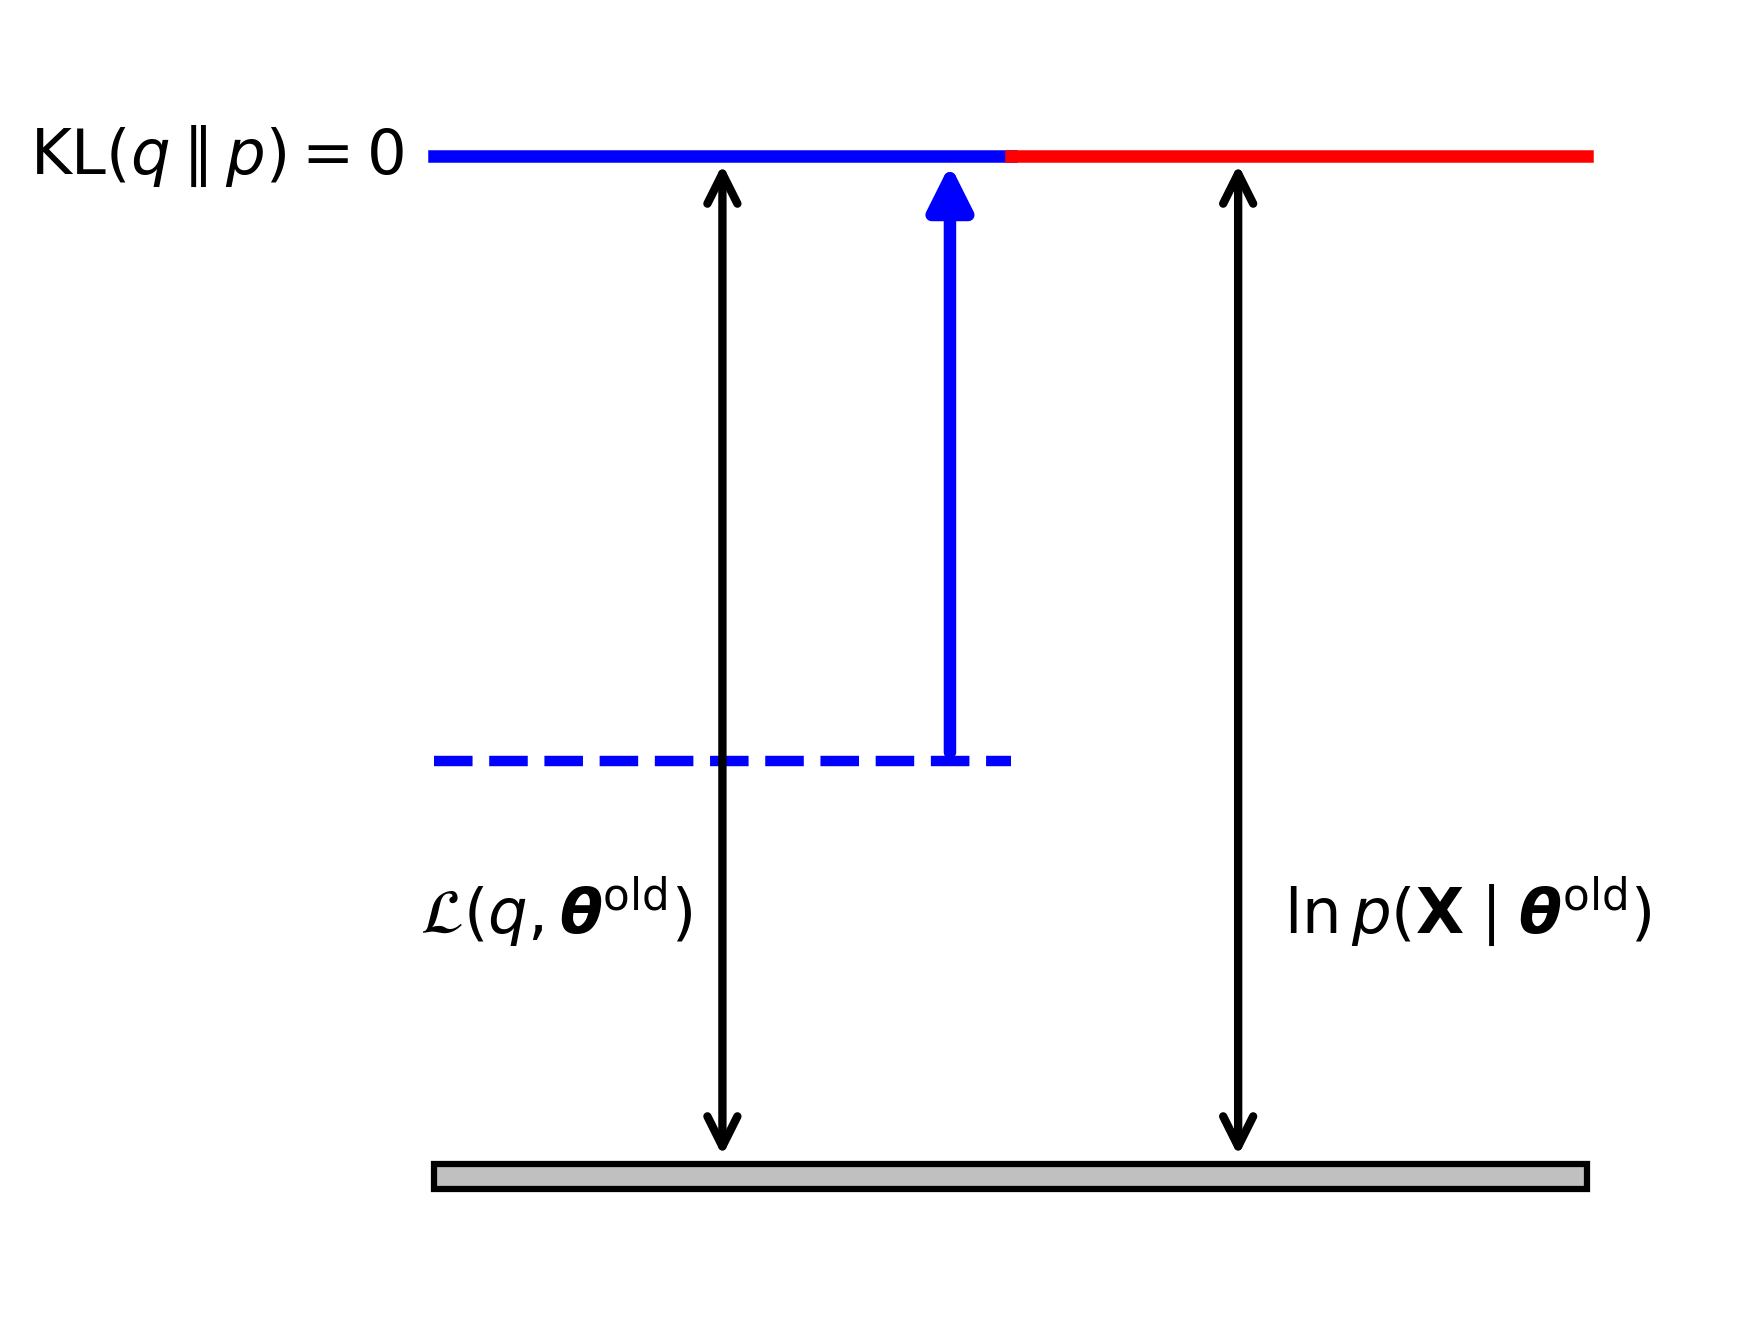

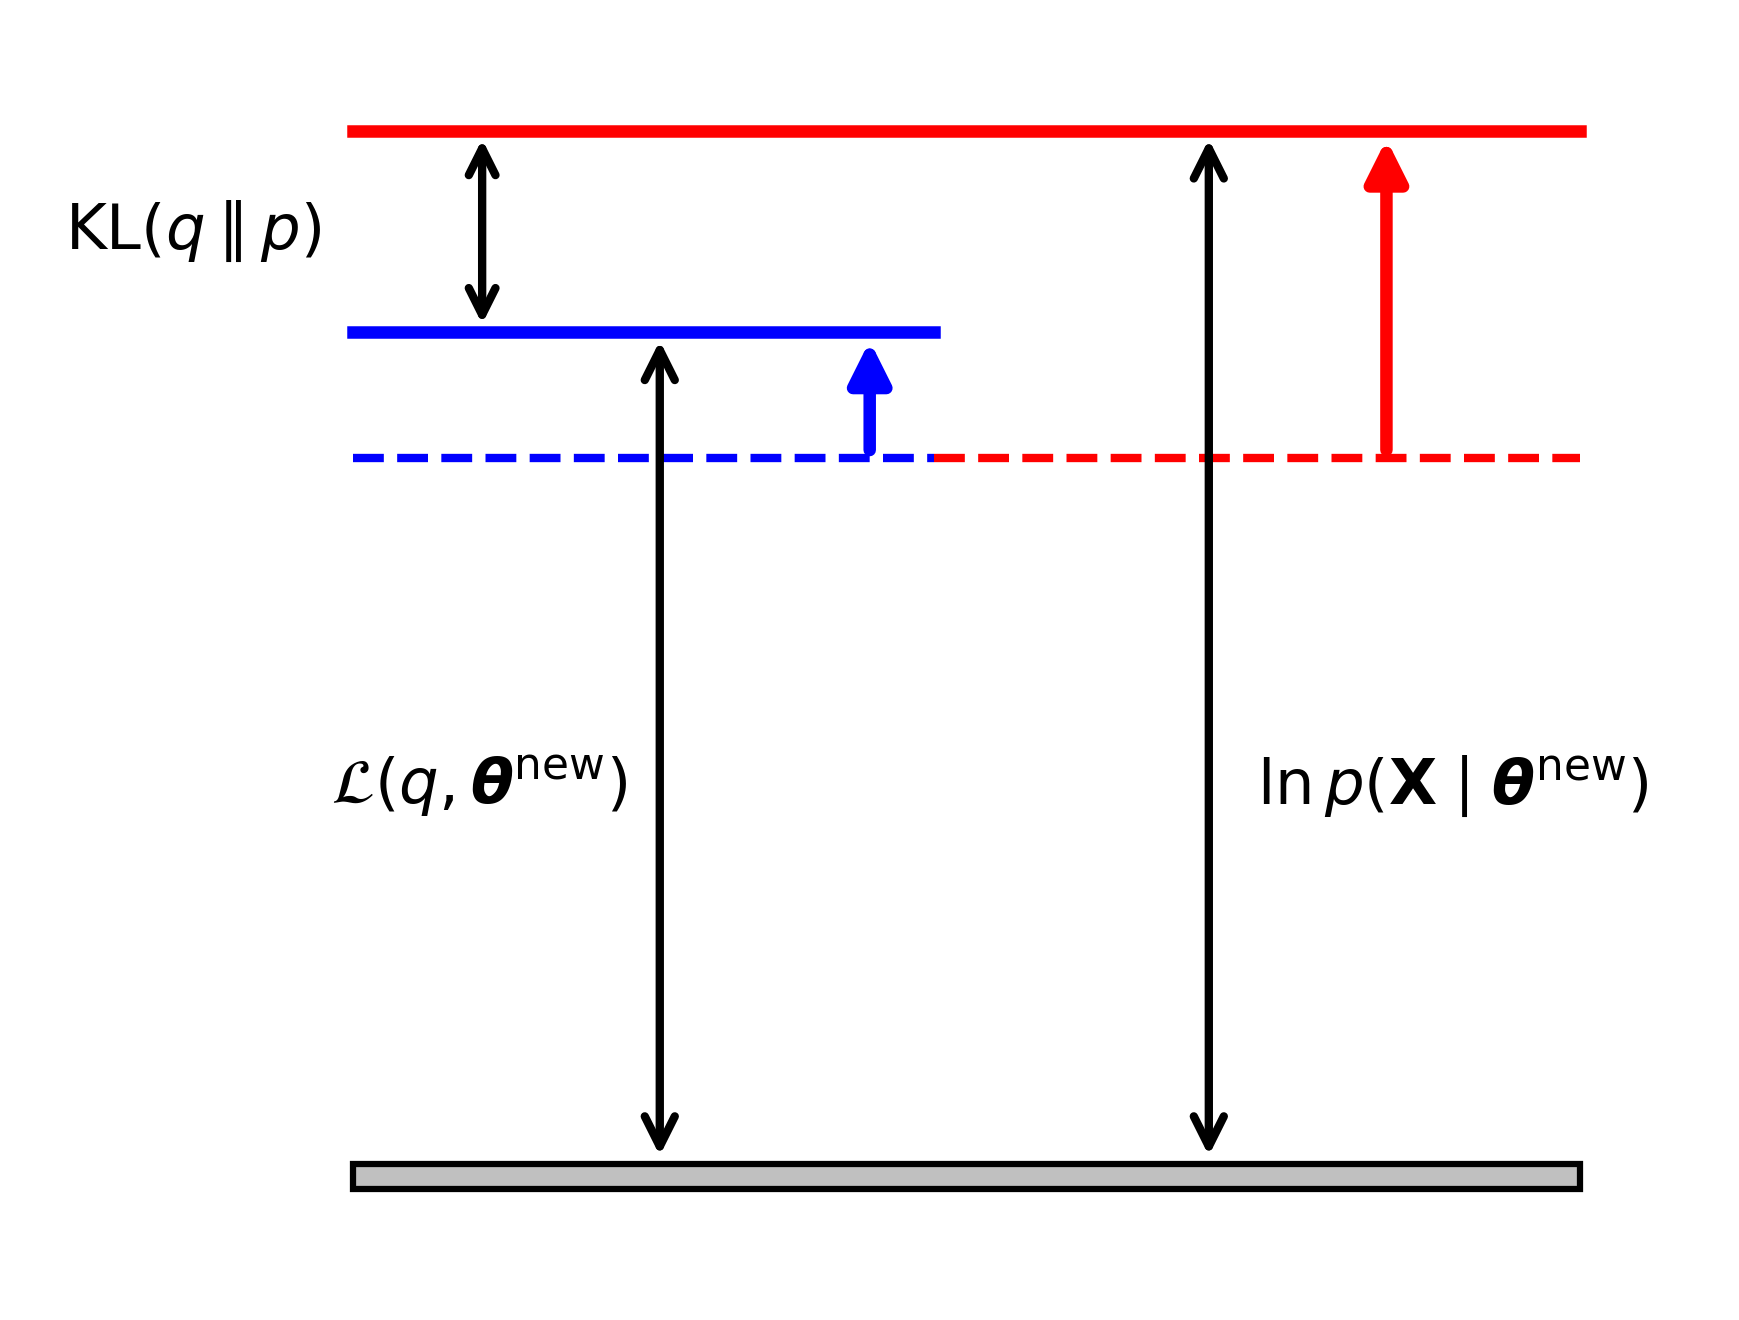

In [3]:
# Figure 15.14 & 15.15: EステップとMステップの幾何学的解釈の表示
fig_path_15_14 = project_root / "15" / "result" / "fig_15_14_elbo_e_step.png"
fig_path_15_15 = project_root / "15" / "result" / "fig_15_15_elbo_m_step.png"

generate_figure_15_14(fig_path_15_14)
generate_figure_15_15(fig_path_15_15)

display(Image(filename=str(fig_path_15_14)))
display(Image(filename=str(fig_path_15_15)))


### 完全データ対数尤度の期待値 $Q(\boldsymbol{\theta}, \boldsymbol{\theta}^{\text{old}})$ との関係

Eステップの解 $q(\mathbf{Z}) = p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta}^{\text{old}})$ を下界の定義式 (15.53) に代入すると：

$$\begin{aligned}
\mathcal{L}(q, \boldsymbol{\theta}) &= \sum_{\mathbf{Z}} p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta}^{\text{old}}) \ln p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\theta}) - \sum_{\mathbf{Z}} p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta}^{\text{old}}) \ln p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta}^{\text{old}}) \\
&= Q(\boldsymbol{\theta}, \boldsymbol{\theta}^{\text{old}}) + \mathrm{const} \tag{15.56}
\end{aligned}$$

ここで、定数項は分布 $q$ の負のエントロピーであり、$\boldsymbol{\theta}$ には依存しません。
第1項 $Q(\boldsymbol{\theta}, \boldsymbol{\theta}^{\text{old}})$ はまさに15.3節で定義した**完全データ対数尤度の期待値**です。
したがって、Mステップにおいて下界 $\mathcal{L}(q, \boldsymbol{\theta})$ を最大化することは、$Q(\boldsymbol{\theta}, \boldsymbol{\theta}^{\text{old}})$ を最大化することと完全に一致することが証明されます。

---

### パラメータ空間におけるEMの挙動 (Figure 15.16)

パラメータ空間 $\boldsymbol{\theta}$ において、下界 $\mathcal{L}(\boldsymbol{\theta}, \boldsymbol{\theta}^{\text{old}})$ は真の対数尤度関数 $\ln p(\mathbf{X} \mid \boldsymbol{\theta})$ の下に位置し、点 $\boldsymbol{\theta}^{\text{old}}$ において**接点（接線・勾配が一致）**を持ちます (Figure 15.16)。
Mステップはこの下に凸な下界関数の頂点 $\boldsymbol{\theta}^{\text{new}}$ を探索し、続くEステップで新しい接線を持つ下界関数を再構築します。


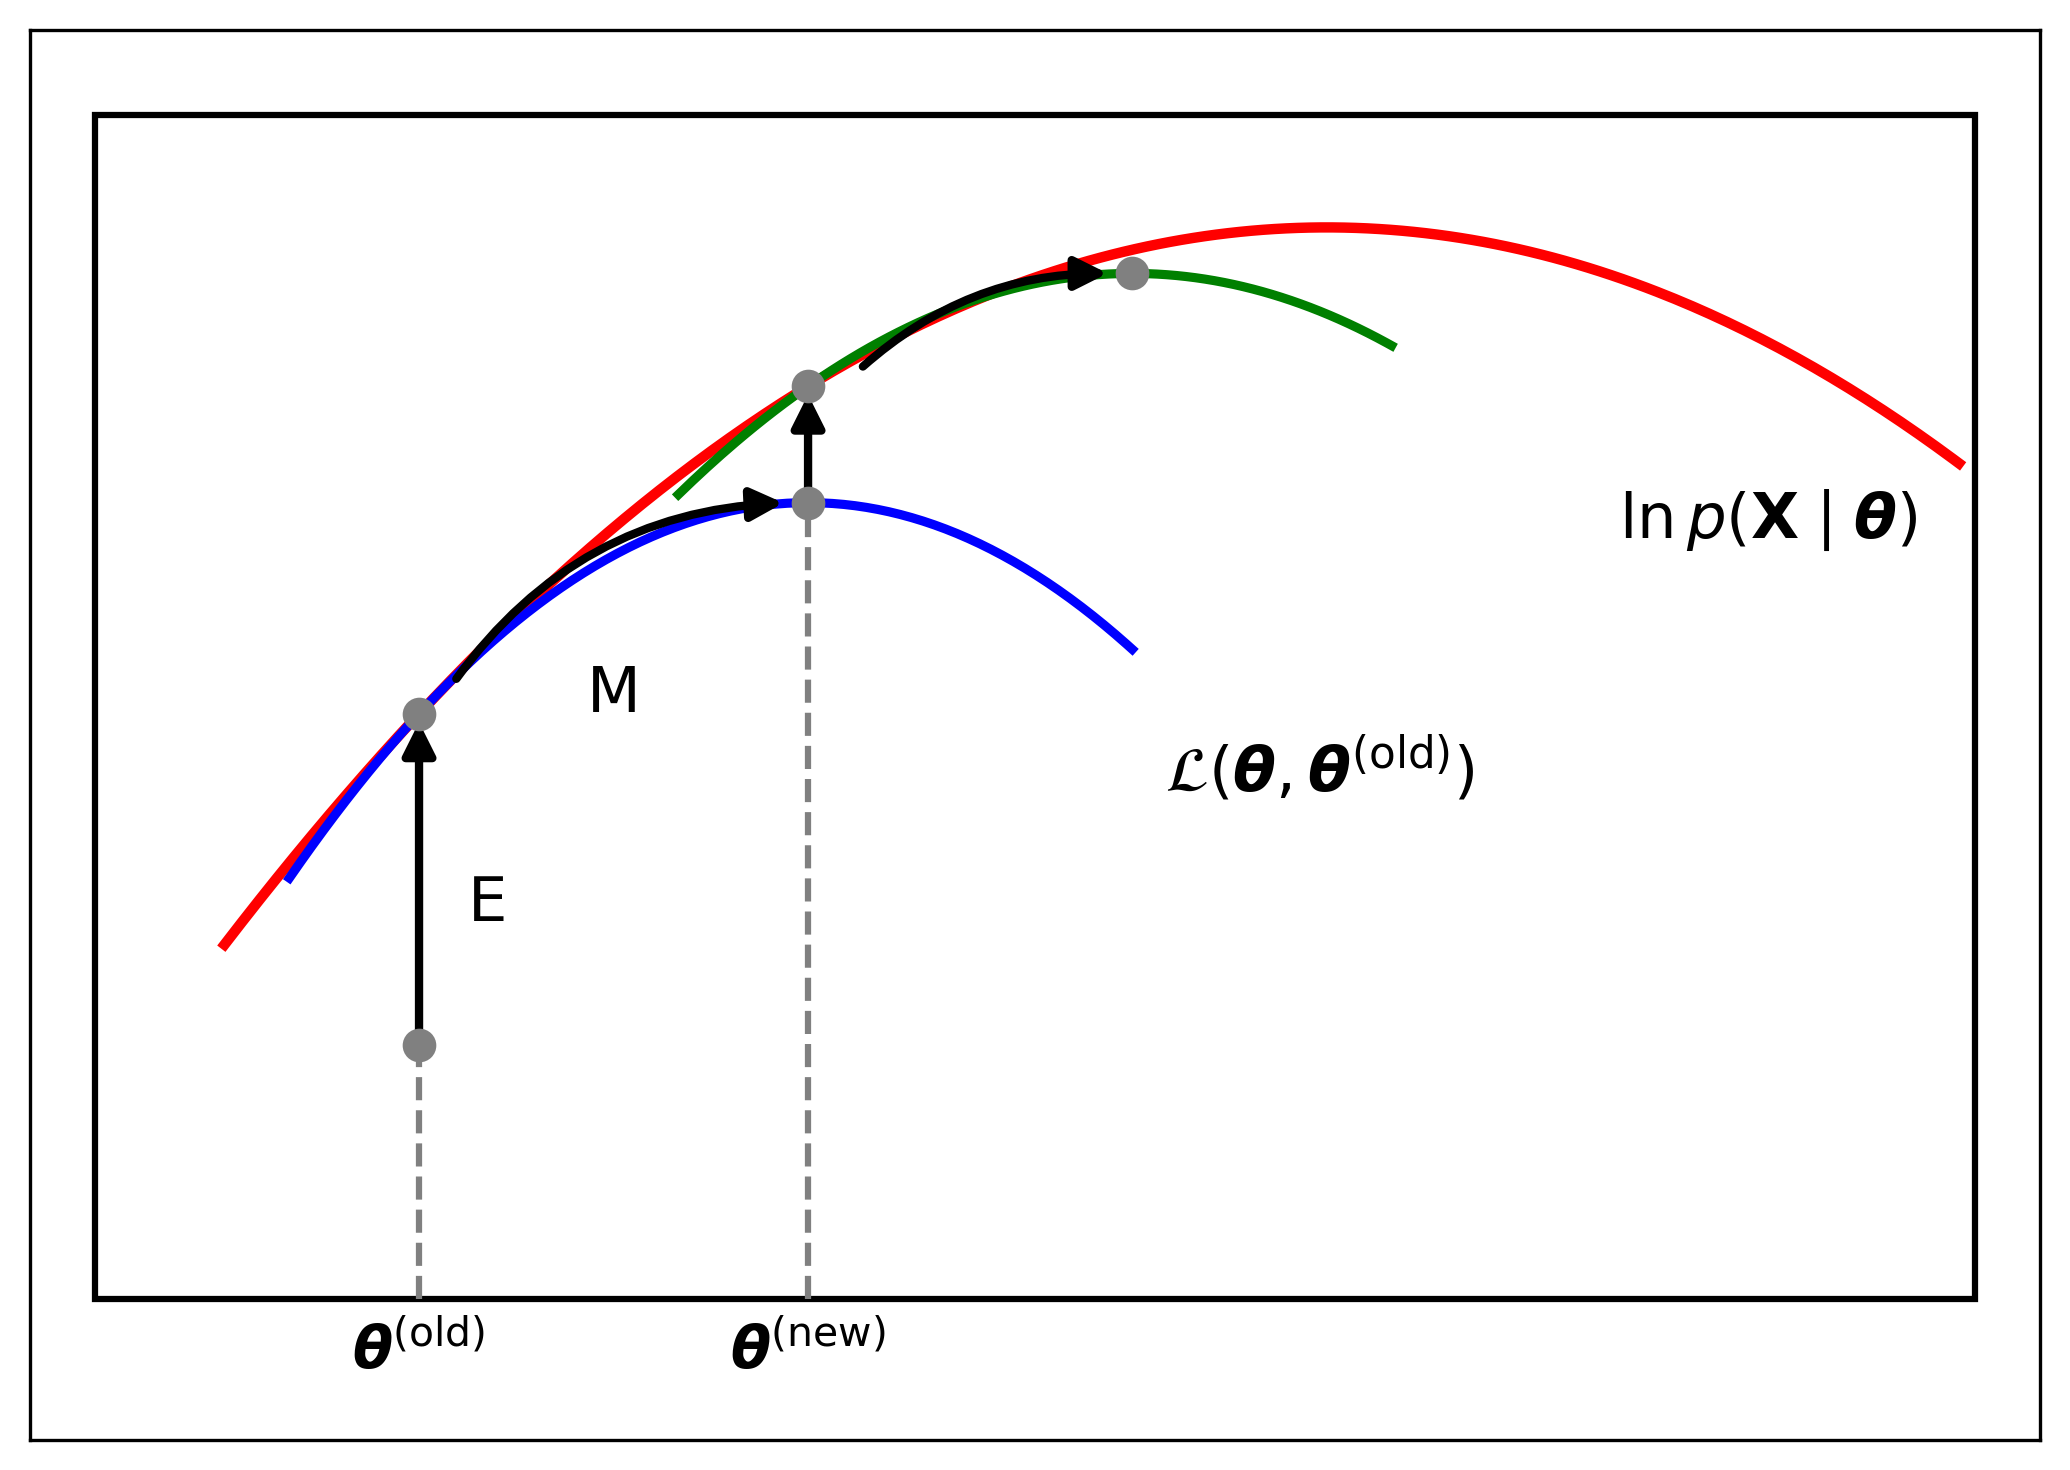

In [4]:
# Figure 15.16: パラメータ空間における接線下界とEMの推移
fig_path_15_16 = project_root / "15" / "result" / "fig_15_16_em_parameter_space.png"
generate_figure_15_16(fig_path_15_16)

display(Image(filename=str(fig_path_15_16)))


## 3. 第15.4.2項 独立同分布データ (Independent and identically distributed data)

$N$ 個の独立同分布 (i.i.d.) な観測データ $\mathbf{X} = \{\mathbf{x}_1, \ldots, \mathbf{x}_N\}$ と対応する潜在変数 $\mathbf{Z} = \{\mathbf{z}_1, \ldots, \mathbf{z}_N\}$ を考えます。

同時分布はデータ点ごとに因数分解されます：

$$p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\theta}) = \prod_{n=1}^N p(\mathbf{x}_n, \mathbf{z}_n \mid \boldsymbol{\theta})$$

このとき、事後分布もデータ点ごとに完全に独立に分解されます (テキスト式 15.57)：

$$p(\mathbf{Z} \mid \mathbf{X}, \boldsymbol{\theta}) = \frac{\prod_{n=1}^N p(\mathbf{x}_n, \mathbf{z}_n \mid \boldsymbol{\theta})}{\sum_{\mathbf{Z}} \prod_{n=1}^N p(\mathbf{x}_n, \mathbf{z}_n \mid \boldsymbol{\theta})} = \prod_{n=1}^N p(\mathbf{z}_n \mid \mathbf{x}_n, \boldsymbol{\theta}) \tag{15.57}$$

これは、各データ点 $\mathbf{x}_n$ に対する負担率 $\gamma(z_{nk})$ の計算が、**他のすべてのデータ点から完全に独立**して行えることを示しています。

---

### 完全データのグラフィカルモデル (Figure 15.10)
潜在変数 $\mathbf{z}_n$ が観測された完全データ（Complete data）では、$\mathbf{z}_n$ と $\mathbf{x}_n$ の双方が観測変数（青色塗りつぶし）となり、各パラメータ $\boldsymbol{\pi}, \boldsymbol{\mu}, \mathbf{\Sigma}$ の最尤推定量は閉じた形で解析的に解けます。

### 系列データへの拡張: 隠れマルコフモデル (HMM, Figure 15.11)
データが独立ではなく時系列順序を持つ場合、潜在変数をマルコフ連鎖 $\mathbf{z}_1 \to \mathbf{z}_2 \to \dots \to \mathbf{z}_N$ として結合した**隠れマルコフモデル (Hidden Markov Model; HMM)** へと自然に拡張されます。


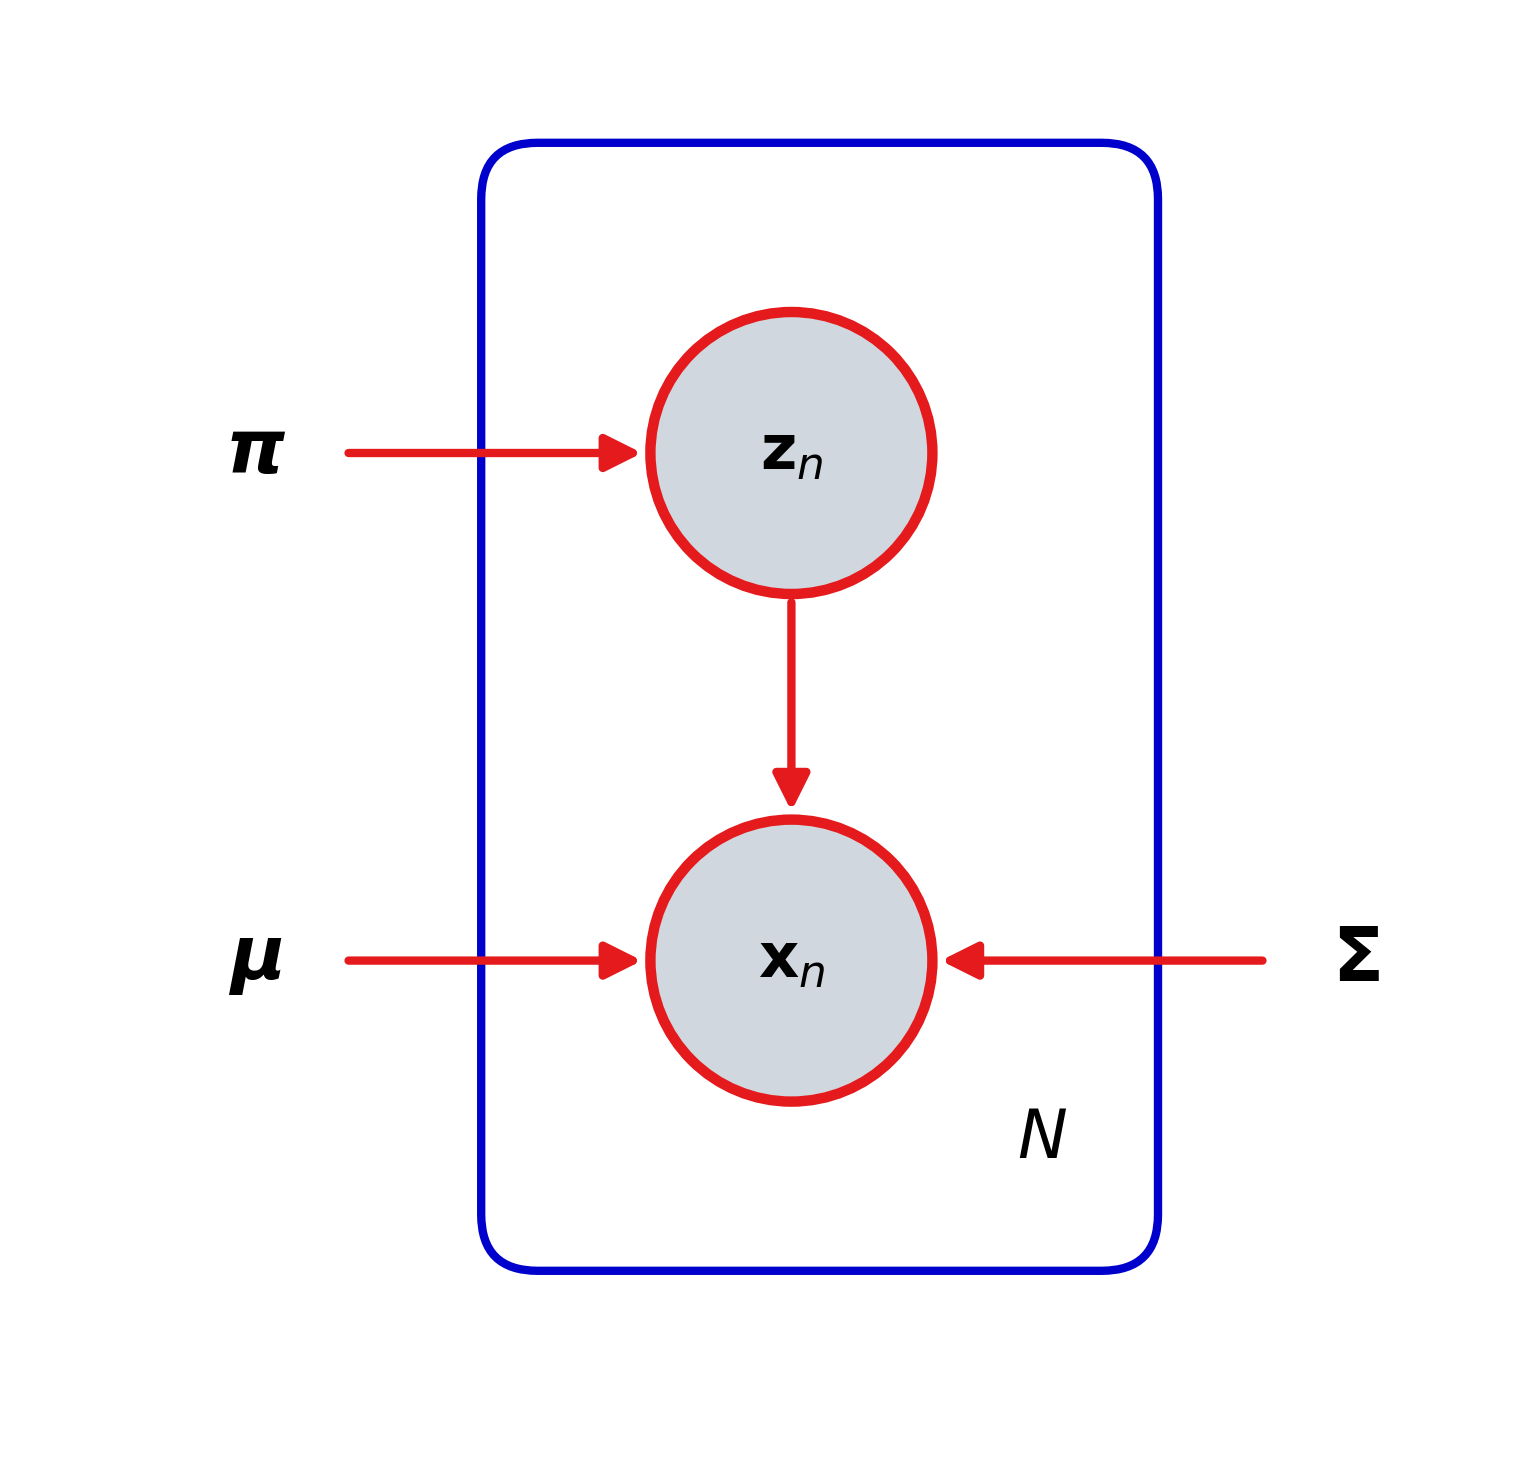

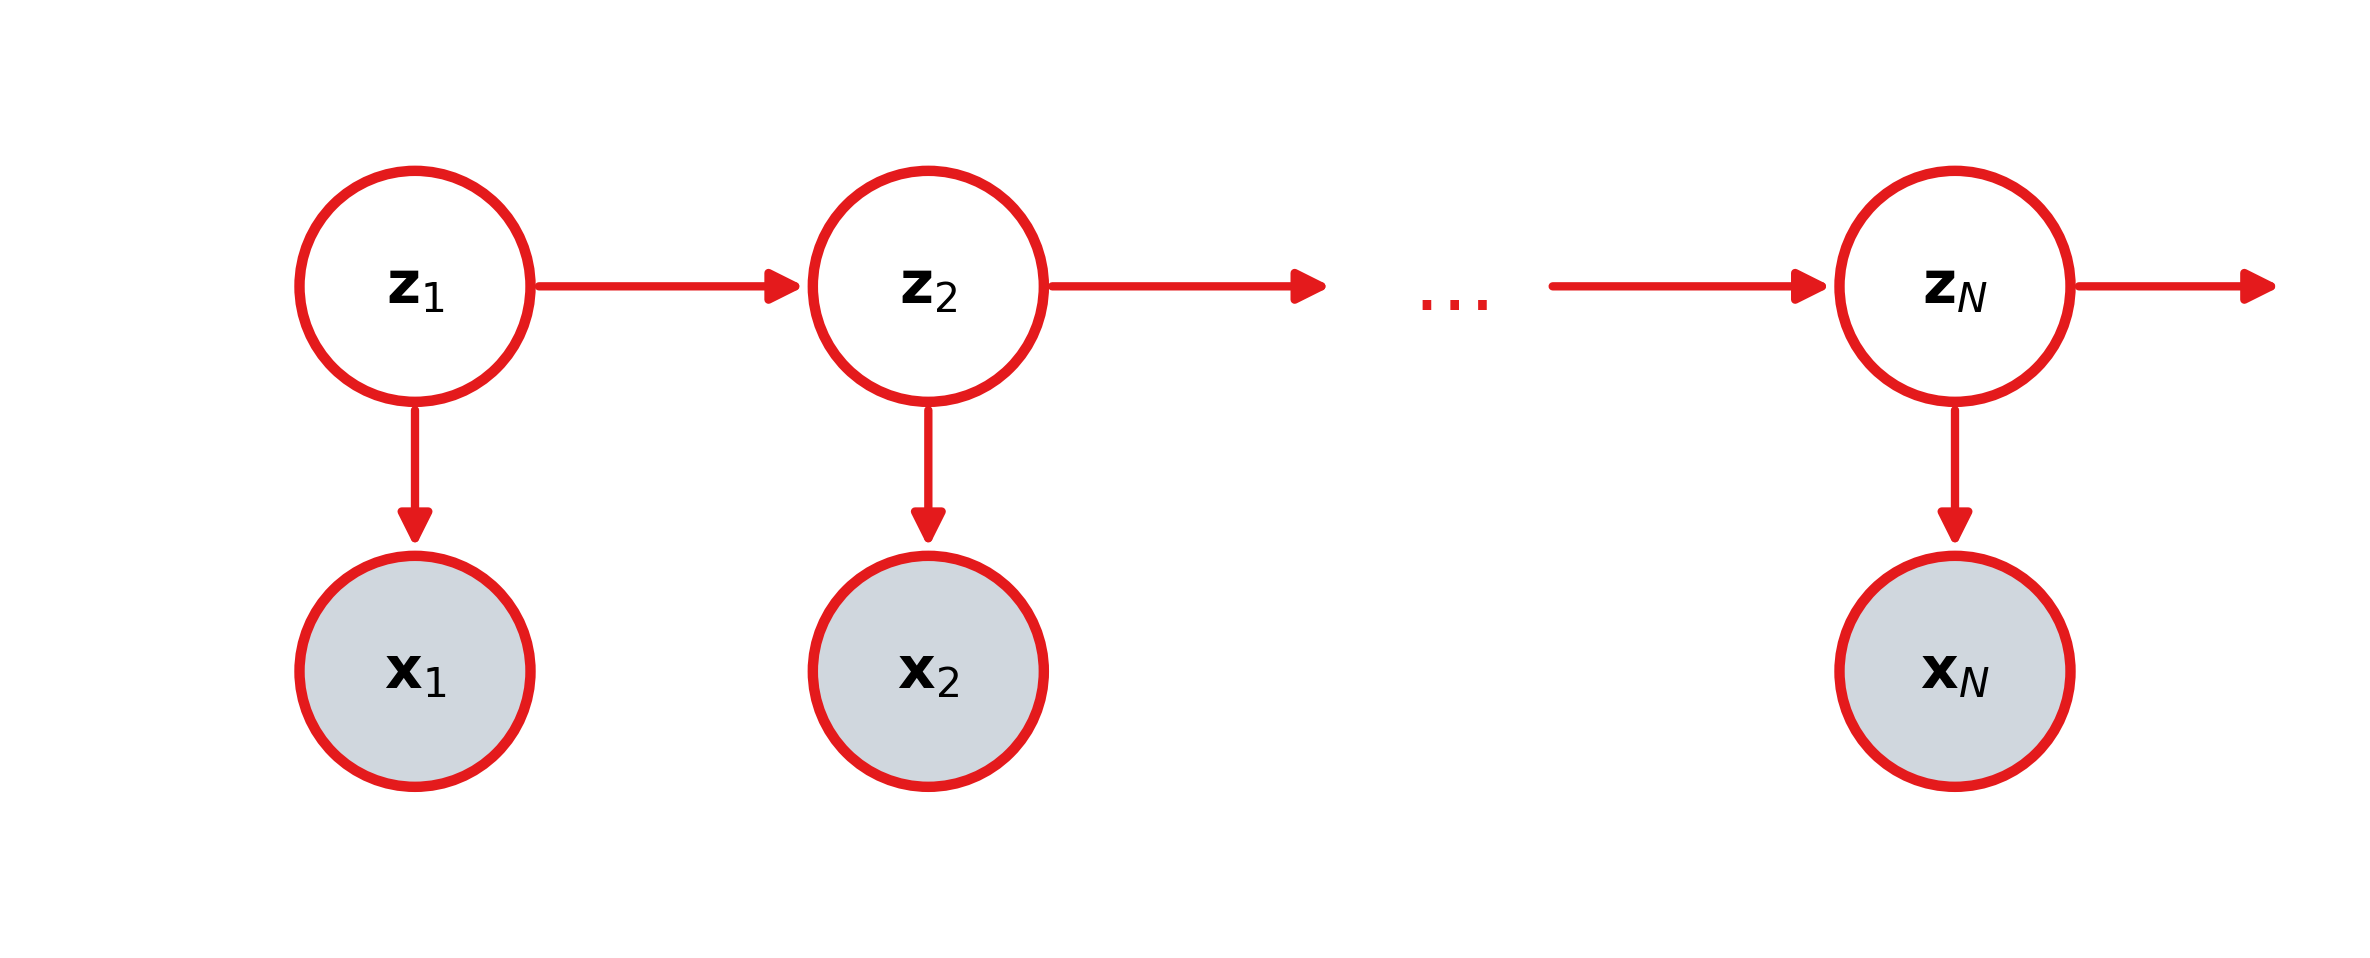

In [5]:
# Figure 15.10 & 15.11: グラフィカルモデルの表示
fig_path_15_10 = project_root / "15" / "result" / "fig_15_10_complete_data_graphical_model.png"
fig_path_15_11 = project_root / "15" / "result" / "fig_15_11_hmm_graphical_model.png"

generate_figure_15_10(fig_path_15_10)
generate_figure_15_11(fig_path_15_11)

display(Image(filename=str(fig_path_15_10)))
display(Image(filename=str(fig_path_15_11)))


## 4. 第15.4.3項 パラメータの事前分布 (Parameter priors: MAP EM)

パラメータ $\boldsymbol{\theta}$ に対して事前分布 $p(\boldsymbol{\theta})$ を導入した**最大事後確率 (MAP) 推定**にも、EMアルゴリズムはそのまま適用できます。

ベイズの定理より：

$$\ln p(\boldsymbol{\theta} \mid \mathbf{X}) = \ln p(\boldsymbol{\theta}, \mathbf{X}) - \ln p(\mathbf{X}) \tag{15.58}$$

変分分解式 (15.52) を代入すると：

$$\ln p(\boldsymbol{\theta} \mid \mathbf{X}) = \mathcal{L}(q, \boldsymbol{\theta}) + \mathrm{KL}(q \parallel p) + \ln p(\boldsymbol{\theta}) - \ln p(\mathbf{X}) \ge \mathcal{L}(q, \boldsymbol{\theta}) + \ln p(\boldsymbol{\theta}) - \ln p(\mathbf{X}) \tag{15.59}$$

- **Eステップ**: $q(\mathbf{Z})$ は $\mathcal{L}(q, \boldsymbol{\theta})$ にしか現れないため、標準の最尤EMと全く同じ式（事後負担率の計算）になります。
- **Mステップ**: $\mathcal{L}(q, \boldsymbol{\theta}) + \ln p(\boldsymbol{\theta})$ を最大化します。事前分布 $\ln p(\boldsymbol{\theta})$ が正則化項として働き、**15.2節で指摘した混合ガウスモデルの特異点問題（分散が 0 に縮退して尤度が無限大発散する現象）を完全に根絶**します。

---

## 5. 第15.4.4項 一般化EM (Generalized EM; GEM)

複雑な深層確率モデルでは、厳密な Eステップや Mステップの解析解が存在しない（intractable）場合があります。
このとき、厳密な最大化を行わずとも、下界 $\mathcal{L}(q, \boldsymbol{\theta})$ を**単に改善（増加）させるだけ**で対数尤度の単調増加が保証されるという強力な拡張が**一般化EM (GEM)** です。

1. **Mステップの一般化**:
   - 勾配降下法 / 勾配上昇法などを用いてパラメータを $\mathcal{L}$ が増加する方向へ更新する。
   - 条件付き最大化 (Expectation Conditional Maximization; ECM): パラメータを複数のブロックに分割し、1ブロックずつ交互に最適化する。
2. **Eステップの一般化**:
   - $q(\mathbf{Z})$ の族を制限し、真の事後分布に完全に一致させずに変分下界を部分的に改善する（**変分推論; Variational Inference**, 第16章および第19章の根幹）。


## 6. 第15.4.5項 逐次型EM (Sequential EM)

ビッグデータ環境やストリーミングデータでは、全データ $N$ 個を一括処理するバッチEMはメモリや計算効率の面で非効率です。
データ点が i.i.d. である性質を利用し、1データ点 $m$ ずつ逐次的に更新する**逐次型EM (Sequential / Incremental EM)** が構築されます。

### 十分統計量のインクリメンタル更新式

データ点 $m$ に対する負担率が $\gamma^{\text{old}}(z_{mk})$ から $\gamma^{\text{new}}(z_{mk})$ に変化したとき、有効サンプル数および平均ベクトルの十分統計量は次のように更新されます (テキスト式 15.60 - 15.61)：

$$N_k^{\text{new}} = N_k^{\text{old}} + \gamma^{\text{new}}(z_{mk}) - \gamma^{\text{old}}(z_{mk}) \tag{15.61}$$

$$\boldsymbol{\mu}_k^{\text{new}} = \boldsymbol{\mu}_k^{\text{old}} + \frac{\gamma^{\text{new}}(z_{mk}) - \gamma^{\text{old}}(z_{mk})}{N_k^{\text{new}}} (\mathbf{x}_m - \boldsymbol{\mu}_k^{\text{old}}) \tag{15.60}$$

1ステップあたりの計算量はデータ総数 $N$ に依存せず $O(K D^2)$ であり、極めて高速に収束します。


In [6]:
# 逐次型EM (Sequential EM) の数値検証 (Old Faithful データ)
seq_em = SequentialGaussianMixtureEM(n_components=2, n_epochs=5)
init_means = np.array([[-1.5, 1.0], [1.5, -1.0]])
init_covs = np.array([np.eye(2), np.eye(2)])
init_weights = np.array([0.5, 0.5])

seq_em.fit(X_std, init_means, init_covs, init_weights)

print("Sequential EM Log-Likelihood progression across epochs:")
for epoch, ll in enumerate(seq_em.history_log_likelihood_):
    print(f"  Epoch {epoch:2d}: ln p(X) = {ll:.4f}")

# MAP EM による特異点抑制の検証
map_em = MAPGaussianMixtureEM(n_components=2, max_iter=10, alpha_prior=3.0, beta_cov_prior=1.0)
map_em.fit(X_std, init_means, init_covs, init_weights)

print("\nMAP EM fitted mixing weights:")
print(f"  pi_1 = {map_em.weights_[0]:.4f}, pi_2 = {map_em.weights_[1]:.4f}")
print("MAP EM converged without singular covariances!")


Sequential EM Log-Likelihood progression across epochs:
  Epoch  0: ln p(X) = -1150.1987
  Epoch  1: ln p(X) = -510.9762
  Epoch  2: ln p(X) = -452.4813
  Epoch  3: ln p(X) = -436.0308
  Epoch  4: ln p(X) = -416.3695
  Epoch  5: ln p(X) = -392.3523

MAP EM fitted mixing weights:
  pi_1 = 0.3646, pi_2 = 0.6354
MAP EM converged without singular covariances!


## 7. 第15章全体の総括と第16章（連続潜在変数）への展望

本章「離散潜在変数 (Discrete Latent Variables)」では、機械学習における教師なし学習・確率的クラスタリングの最重要基礎を体系的に網羅しました：

### 第15章の理論的マイルストーン

1. **15.1 K-means クラスタリング**:
   - 決定論的・ハードなクラスタ割当と歪み尺度 $J$ の交互最小化。
2. **15.2 混合ガウスモデル (GMM)**:
   - 離散潜在変数 $\mathbf{z}$ による線形重ね合わせ、事後負担率 $\gamma(z_k)$、最尤法の特異点問題。
3. **15.3 期待値最大化法 (EMアルゴリズム)**:
   - Eステップ（事後確率計算）と Mステップ（パラメータ更新）の反復、K-meansへの極限収束 ($\epsilon \to 0$)、ベルヌーイ混合モデル。
4. **15.4 変分下界 (ELBO)**:
   - 分解恒等式 $\ln p(\mathbf{X} \mid \boldsymbol{\theta}) = \mathcal{L}(q, \boldsymbol{\theta}) + \mathrm{KL}(q \parallel p)$ の数学的確立。
   - EMの単調収束性の厳密証明、一般化EM、MAP正則化、逐次型EM。

---

### 次章への展望: 第16章 連続潜在変数 (Continuous Latent Variables)
本章で扱った潜在変数 $\mathbf{Z}$ は、データがどの離散クラスタに属するかを表す有限次元の離散変数でした。
しかし、現実の画像データや自然言語埋め込みなど多くの高次元データは、本質的に低次元の**連続的な多様体 (continuous manifold)** 上に分布しています。

次章（第16章）では、潜在変数 $\mathbf{z} \in \mathbb{R}^M$ を連続変数へと拡張し、**主成分分析 (PCA)**、**確率的主成分分析 (PPCA)**、**因子分析 (Factor Analysis)**、そして連続変分下界に基づく生成モデルの深遠な世界を探究します！
